`conda activate r_python`

In [1]:
library(reshape2)
library(Seurat)
library(NMF)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(tidyverse)
library(ComplexHeatmap)
library(RColorBrewer)
library(jsonlite)
library(circlize)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp

The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect


Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following object

In [2]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

### Score cells for signature

### Using UCell

#### Curated signatures

In [8]:
data <- fromJSON("../../data/dmg_spectra_dict_myeloid_no_global.json")
data

$global
$global$nieto21_Macrophages_SPP1
 [1] "SPP1"     "APOE"     "C1QB"     "C1QA"     "APOC1"    "C1QC"    
 [7] "HLA.DRA"  "CTSB"     "CD68"     "SELENOP"  "HLA.DRB1" "HLA.DPB1"
[13] "CD14"     "FCER1G"   "CD74"     "FCGR3A"   "CD163"    "MSR1"    
[19] "A2M"     

$global$nieto21_TAMs_C1QC
 [1] "C1QB"    "C1QA"    "C1QC"    "APOE"    "SELENOP" "CD14"    "SPP1"   
 [8] "CD68"    "CD163"   "CXCL2"   "CSF1R"   "FCGR3A"  "IL1B"    "PLTP"   
[15] "MRC1"    "SIRPA"   "CD40"   

$global$nieto21_Macrophages_CXCL10
 [1] "CXCL10"   "IL1RN"    "CCL2"     "CCL8"     "CXCL11"   "LYZ"     
 [7] "FCN1"     "S100A9"   "S100A8"   "CD68"     "CD14"     "SERPINA1"
[13] "LILRB2"   "LGALS9"   "FCGR2A"   "IL1B"     "LILRB4"   "CD274"   

$global$nieto21_Macro_and_mono_prolif
[1] "SPP1"    "C1QC"    "C1QB"    "C1QA"    "PLTP"    "SELENOP" "LYVE1"  

$global$nieto21_Monocytes_tumor_infiltrating
 [1] "S100A9" "S100A8" "CXCL8"  "IL1B"   "CCL3L3" "LYZ"    "G0S2"   "SOD2"  
 [9] "CXCL2"  "CXCL3"  "CD14"   "CSF3R" 

$global$nieto21_DC1
[1] "HLA-DPA1" "IDO1"     "C1orf54"  "CLEC9A"   "SERPINB1" "XCR1"    

$global$`nieto21_DC2_CD1C+`
[1] "HLA-DRA"  "CST3"     "HLA-DPB1" "HLA-DPA1" "HLA-DQB1" "FCER1A"   "CD1C"    

$global$nieto21_DC3_LAMP3
[1] "FSCN1"    "LAMP3"    "CCR7"     "IDO1"     "HLA-DQA1" "CD274"   

$global$`nieto21_DC4_CD1C-`
[1] "LST1"     "AIF1"     "SERPINA1" "FCGR3A"   "LILRB2"   "CSF1R"   

$global$nieto21_pDC
[1] "IRF7"  "IRF8"  "TCF4"  "GZMB"  "IL3RA"

$global$nieto21_Mast_cells
[1] "TPSB2"  "TPSAB1" "KIT"   

$global$ma2022_IFN_TAM
 [1] "CASP1"    "CASP4"    "CCL2"     "CCL3"     "CCL4"     "CCL7"    
 [7] "CCL8"     "CD274"    "CD40"     "CXCL2"    "CXCL3"    "CXCL9"   
[13] "CXCL10"   "CXCL11"   "IDO1"     "IFI6"     "IFIT1"    "IFIT2"   
[19] "IFIT3"    "IFITM1"   "IFITM3"   "IRF1"     "IRF7"     "ISG15"   
[25] "LAMP3"    "PDCD1LG2" "TNFSF10"  "C1QA"     "C1QC"     "CD38"    
[31] "IL4I1"    "TNFSF10"  "IFI44L"  

$global$ma2022_Inflam_TAM
 [1] "CCL2"   "CCL3"   "CCL4"   "CCL5"   "CCL20"  "CCL3L1" "CCL3L3" "CCL4L2"
 [9] "CCL4L4" "CXCL1"  "CXCL2"  "CXCL3"  "CXCL5"  "CXCL8"  "G0S2"   "IL1B"  
[17] "IL1RN"  "IL6"    "INHBA"  "KLF2/6" "NEDD9"  "PMAIP1" "S100A8" "S100A9"
[25] "SPP1"  

$global$ma2022_LA_TAM
 [1] "ACP5"   "AOPE"   "APOC1"  "ATF1"   "C1QA"   "C1QB"   "C1QC"   "CCL18" 
 [9] "CD163"  "CD36"   "CD63"   "CHI3L1" "CTSB"   "CTSD"   "CTSL"   "F13A1" 
[17] "FABP5"  "FOLR2"  "GPNMB"  "IRF3"   "LGALS3" "LIPA"   "LPL"    "MACRO" 
[25] "MerTK"  "MMP7"   "MMP9"   "MMP12"  "MRC1"   "NR1H3"  "NRF1"   "NUPR1" 
[33] "PLA2G7" "RNASE1" "SPARC"  "SPP1"   "TFDP2"  "TREM2"  "ZEB1"  

$global$ma2022_Angio_TAM
 [1] "ADAM8"    "AREG"     "BNIP3"    "CCL2"     "CCL4"     "CCL20"   
 [7] "CD163"    "CD300E"   "CD44"     "CD55"     "CEBPB"    "CLEC5A"  
[13] "CTSB"     "EREG"     "FCN1"     "FLT1"     "FN1"      "HES1"    
[19] "IL1B"     "IL1RN"    "IL8"      "MAF"      "MIF"      "NR1H3"   
[25] "OLR1"     "PPARG"    "S100A8"   "S100A9"   "S100A12"  "SERPINB2"
[31] "SLC2A1"   "SPIC"     "SPP1"     "THBS1"    "TIMP1"    "VCAN"    
[37] "VEGFA"   

$global$ma2022_Reg_TAM
 [1] "CCL2"     "CD274"    "CD40"     "CD80"     "CD86"     "CHIT1"   
 [7] "CX3CR1"   "HLA-A/C"  "HLA-DQA1" "HLA-DQB1" "HLA-DRA"  "HLA-DRB1"
[13] "HLA-DRB5" "ICOSLG"   "IL-10"    "ITGA4"    "LGALS9"   "MACRO"   
[19] "MRC1"     "TGFB2"   

$global$ma2022_Prolif_TAM
 [1] "CCNA2"    "CDC45"    "CDK1"     "H2AFC"    "HIST1H4C" "HMGB1"   
 [7] "HMGN2"    "MKI67"    "RRM2 "    "STMN1"    "TOP2A"    "TUBA1B"  
[13] "TUBB"     "TYMS"    

$global$ma2022_Microglia_like_
[1] "BIN1"    "C1QC"    "CX3CR1"  "NAV3"    "P2RY12"  "SALL1"   "SIGLEC8"
[8] "SLC1A3" 

$global$ma2022_Classical_TIM
 [1] "S100A4"  "S100A6"  "S100A8"  "S100A9"  "S100A12" "S100A13" "AREG"   
 [8] "CCL4"    "CCR2"    "CD14 "   "CD300E"  "CD36"    "CEBPD"   "CLEC11A"
[15] "CLEC12A" "CSF1R"   "CTSS"    "CX3CR1"  "CXCL2"   "CXCR4"   "EGR1"   
[22] "FCN1"    "FOS"     "FTH1"    "IL1B"    "ITGAM"   "JUNB"    "LGALS2" 
[29] 

In [9]:
signatures <- data$global
length(signatures)

[1] 54

In [10]:
signature_names <- names(signatures)
signature_names

[1] "nieto21_Macrophages_SPP1"              
 [2] "nieto21_TAMs_C1QC"                     
 [3] "nieto21_Macrophages_CXCL10"            
 [4] "nieto21_Macro_and_mono_prolif"         
 [5] "nieto21_Monocytes_tumor_infiltrating"  
 [6] "nieto21_DC1"                           
 [7] "nieto21_DC2_CD1C+"                     
 [8] "nieto21_DC3_LAMP3"                     
 [9] "nieto21_DC4_CD1C-"                     
[10] "nieto21_pDC"                           
[11] "nieto21_Mast_cells"                    
[12] "ma2022_IFN_TAM"                        
[13] "ma2022_Inflam_TAM"                     
[14] "ma2022_LA_TAM"                         
[15] "ma2022_Angio_TAM"                      
[16] "ma2022_Reg_TAM"                        
[17] "ma2022_Prolif_TAM"                     
[18] "ma2022_Microglia_like_"                
[19] "ma2022_Classical_TIM"                  
[20] "ma2022_Non_classical_Mono"             
[21] "ma2022_Intermediate_Mono"              
[22] "ma2022_M1_Xiao"                        
[23] "ma2022_M2_Xiao"                        
[24] "ma2022_M1_Cheng"                       
[25] "ma2022_M2_Cheng"                       
[26] "ma2022_Angiogenesis_"                  
[27] "ma2022_Phagocytosis"                   
[28] "miller2023_Microglia"                  
[29] "miller2023_C1Q_Immunosuppressive"      
[30] "miller2023_Neutrophil"                 
[31] "miller2023_Scavenger_Immunosuppressive"
[32] "miller2023_G2_M"                       
[33] "miller2023_IFN_Response"               
[34] "miller2023_IL1B_Inflammatory"          
[35] "miller2023_cDC"                        
[36] "miller2023_G1_S"                       
[37] "miller2023_Hypoxia"                    
[38] "miller2023_CXCR4_Inflammatory"         
[39] "miller2023_HS_UPR"                     
[40] "miller2023_Macrophage"                 
[41] "miller2023_Monocyte"                   
[42] "gavish23_Lipid_associated"             
[43] "gavish23_Monocyte_Secreted"            
[44] "gavish23_Cell_cycle"                   
[45] "gavish23_Interferon"                   
[46] "gavish23_MES_Glycolysis"               
[47] "gavish23_MAC1"                         
[48] "gavish23_Stress_HSP"                   
[49] "gavish23_MAC2"                         
[50] "gavish23_Proteasomal_degradation"      
[51] "gavish23_MAC3"                         
[52] "gavish23_MYC_Mitochondria"             
[53] "gavish23_Unfolded_protein_response"    
[54] "gavish23_Respiration"

In [11]:
# Define a function to correct gene names
correct_gene_names <- function(gene_list) {
  corrected_list <- lapply(gene_list, function(genes) {
    # Replace incorrect gene names
    genes <- gsub("HLA.DRA", "HLA-DRA", genes)
    genes <- gsub("HLA.DRB1", "HLA-DRB1", genes)
    genes <- gsub("HLA.DPB1", "HLA-DPB1", genes)
    genes <- gsub("AOPE", "APOE", genes)
    genes <- gsub("KLF2/6", "KLF2", genes)
    genes <- gsub("AOPE", "APOE", genes)
    genes <- gsub("AOPE", "APOE", genes)
    genes <- gsub("HLA-A/C", "HLA-A", genes)
    genes <- gsub("IL-10", "IL10", genes)
    genes <- gsub("MACRO", "MARCO", genes)
    genes <- gsub("IL23", "APOE", genes)
    genes <- gsub("FASL", "FASLG", genes)
    genes <- gsub("SEPP1", "SELENOP", genes)
    genes <- gsub("VIMP", "SELENOS", genes)
    genes <- gsub("SELM", "SELENOM", genes)
    genes <- gsub("IL8", "CXCL8", genes)
    genes <- gsub("AOPE", "APOE", genes)
    genes <- gsub("AOPE", "APOE", genes)
    genes <- gsub("RARRES3", "PLAAT4", genes)
    genes <- gsub("PLA2G16", "PLAAT3", genes)
    genes <- gsub("FAM26F", "CALHM6", genes)
    genes <- gsub("MerTK", "MERTK", genes)
    genes <- gsub(" ", "", genes)


    # Add more corrections if needed
    
    # Split genes into a vector
    gene_vector <- unlist(strsplit(genes, "'"))
    # Remove empty elements
    gene_vector <- gene_vector[gene_vector != ""]
    return(gene_vector)
  })
  return(corrected_list)
}

In [12]:
corrected_signatures <- correct_gene_names(signatures)
corrected_signatures

$nieto21_Macrophages_SPP1
 [1] "SPP1"     "APOE"     "C1QB"     "C1QA"     "APOC1"    "C1QC"    
 [7] "HLA-DRA"  "CTSB"     "CD68"     "SELENOP"  "HLA-DRB1" "HLA-DPB1"
[13] "CD14"     "FCER1G"   "CD74"     "FCGR3A"   "CD163"    "MSR1"    
[19] "A2M"     

$nieto21_TAMs_C1QC
 [1] "C1QB"    "C1QA"    "C1QC"    "APOE"    "SELENOP" "CD14"    "SPP1"   
 [8] "CD68"    "CD163"   "CXCL2"   "CSF1R"   "FCGR3A"  "IL1B"    "PLTP"   
[15] "MRC1"    "SIRPA"   "CD40"   

$nieto21_Macrophages_CXCL10
 [1] "CXCL10"   "IL1RN"    "CCL2"     "CCL8"     "CXCL11"   "LYZ"     
 [7] "FCN1"     "S100A9"   "S100A8"   "CD68"     "CD14"     "SERPINA1"
[13] "LILRB2"   "LGALS9"   "FCGR2A"   "IL1B"     "LILRB4"   "CD274"   

$nieto21_Macro_and_mono_prolif
[1] "SPP1"    "C1QC"    "C1QB"    "C1QA"    "PLTP"    "SELENOP" "LYVE1"  

$nieto21_Monocytes_tumor_infiltrating
 [1] "S100A9" "S100A8" "CXCL8"  "IL1B"   "CCL3L3" "LYZ"    "G0S2"   "SOD2"  
 [9] "CXCL2"  "CXCL3"  "CD14"   "CSF3R" 

$nieto21_DC1
[1] "HLA-DPA1" "IDO1"     "C1orf54"  "CLEC9A"   "SERPINB1" "XCR1"    

$`nieto21_DC2_CD1C+`
[1] "HLA-DRA"  "CST3"     "HLA-DPB1" "HLA-DPA1" "HLA-DQB1" "FCER1A"   "CD1C"    

$nieto21_DC3_LAMP3
[1] "FSCN1"    "LAMP3"    "CCR7"     "IDO1"     "HLA-DQA1" "CD274"   

$`nieto21_DC4_CD1C-`
[1] "LST1"     "AIF1"     "SERPINA1" "FCGR3A"   "LILRB2"   "CSF1R"   

$nieto21_pDC
[1] "IRF7"  "IRF8"  "TCF4"  "GZMB"  "IL3RA"

$nieto21_Mast_cells
[1] "TPSB2"  "TPSAB1" "KIT"   

$ma2022_IFN_TAM
 [1] "CASP1"    "CASP4"    "CCL2"     "CCL3"     "CCL4"     "CCL7"    
 [7] "CCL8"     "CD274"    "CD40"     "CXCL2"    "CXCL3"    "CXCL9"   
[13] "CXCL10"   "CXCL11"   "IDO1"     "IFI6"     "IFIT1"    "IFIT2"   
[19] "IFIT3"    "IFITM1"   "IFITM3"   "IRF1"     "IRF7"     "ISG15"   
[25] "LAMP3"    "PDCD1LG2" "TNFSF10"  "C1QA"     "C1QC"     "CD38"    
[31] "IL4I1"    "TNFSF10"  "IFI44L"  

$ma2022_Inflam_TAM
 [1] "CCL2"   "CCL3"   "CCL4"   "CCL5"   "CCL20"  "CCL3L1" "CCL3L3" "CCL4L2"
 [9] "CCL4L4" "CXCL1"  "CXCL2"  "CXCL3"  "CXCL5"  "CXCL8"  "G0S2"   "IL1B"  
[17] "IL1RN"  "IL6"    "INHBA"  "KLF2"   "NEDD9"  "PMAIP1" "S100A8" "S100A9"
[25] "SPP1"  

$ma2022_LA_TAM
 [1] "ACP5"   "APOE"   "APOC1"  "ATF1"   "C1QA"   "C1QB"   "C1QC"   "CCL18" 
 [9] "CD163"  "CD36"   "CD63"   "CHI3L1" "CTSB"   "CTSD"   "CTSL"   "F13A1" 
[17] "FABP5"  "FOLR2"  "GPNMB"  "IRF3"   "LGALS3" "LIPA"   "LPL"    "MARCO" 
[25] "MERTK"  "MMP7"   "MMP9"   "MMP12"  "MRC1"   "NR1H3"  "NRF1"   "NUPR1" 
[33] "PLA2G7" "RNASE1" "SPARC"  "SPP1"   "TFDP2"  "TREM2"  "ZEB1"  

$ma2022_Angio_TAM
 [1] "ADAM8"    "AREG"     "BNIP3"    "CCL2"     "CCL4"     "CCL20"   
 [7] "CD163"    "CD300E"   "CD44"     "CD55"     "CEBPB"    "CLEC5A"  
[13] "CTSB"     "EREG"     "FCN1"     "FLT1"     "FN1"      "HES1"    
[19] "IL1B"     "IL1RN"    "CXCL8"    "MAF"      "MIF"      "NR1H3"   
[25] "OLR1"     "PPARG"    "S100A8"   "S100A9"   "S100A12"  "SERPINB2"
[31] "SLC2A1"   "SPIC"     "SPP1"     "THBS1"    "TIMP1"    "VCAN"    
[37] "VEGFA"   

$ma2022_Reg_TAM
 [1] "CCL2"     "CD274"    "CD40"     "CD80"     "CD86"     "CHIT1"   
 [7] "CX3CR1"   "HLA-A"    "HLA-DQA1" "HLA-DQB1" "HLA-DRA"  "HLA-DRB1"
[13] "HLA-DRB5" "ICOSLG"   "IL10"     "ITGA4"    "LGALS9"   "MARCO"   
[19] "MRC1"     "TGFB2"   

$ma2022_Prolif_TAM
 [1] "CCNA2"    "CDC45"    "CDK1"     "H2AFC"    "HIST1H4C" "HMGB1"   
 [7] "HMGN2"    "MKI67"    "RRM2"     "STMN1"    "TOP2A"    "TUBA1B"  
[13] "TUBB"     "TYMS"    

$ma2022_Microglia_like_
[1] "BIN1"    "C1QC"    "CX3CR1"  "NAV3"    "P2RY12"  "SALL1"   "SIGLEC8"
[8] "SLC1A3" 

$ma2022_Classical_TIM
 [1] "S100A4"  "S100A6"  "S100A8"  "S100A9"  "S100A12" "S100A13" "AREG"   
 [8] "CCL4"    "CCR2"    "CD14"    "CD300E"  "CD36"    "CEBPD"   "CLEC11A"
[15] "CLEC12A" "CSF1R"   "CTSS"    "CX3CR1"  "CXCL2"   "CXCR4"   "EGR1"   
[22] "FCN1"    "FOS"     "FTH1"    "IL1B"    "ITGAM"   "JUNB"    "LGALS2" 
[29] "LY6C1"   "LY6C2"   "LYZ"     "MAF"     "MAFB"    "MPEG1"   "NFKB1"  
[36] "NFKBIA"  "NLRP3"   "NR4A1"   "NR4A2"   "OSM"     "PTGS2"   "RGS2"

In [13]:
# Find the maximum length among the lists
max_length <- max(sapply(corrected_signatures, length))

# Pad the shorter lists with NA values to make them equal in length
padded_list <- lapply(corrected_signatures, function(x) {
  if (length(x) < max_length) {
    c(x, rep(NA, max_length - length(x)))
  } else {
    x
  }
})

# Convert the padded list to a data frame
nested_df <- as.data.frame(padded_list)

# Rename the columns with the list names
colnames(nested_df) <- names(corrected_signatures)

# Print the resulting data frame
nested_df

nieto21_Macrophages_SPP1,nieto21_TAMs_C1QC,nieto21_Macrophages_CXCL10,nieto21_Macro_and_mono_prolif,nieto21_Monocytes_tumor_infiltrating,nieto21_DC1,nieto21_DC2_CD1C+,nieto21_DC3_LAMP3,nieto21_DC4_CD1C-,nieto21_pDC,⋯,gavish23_Interferon,gavish23_MES_Glycolysis,gavish23_MAC1,gavish23_Stress_HSP,gavish23_MAC2,gavish23_Proteasomal_degradation,gavish23_MAC3,gavish23_MYC_Mitochondria,gavish23_Unfolded_protein_response,gavish23_Respiration
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SPP1,C1QB,CXCL10,SPP1,S100A9,HLA-DPA1,HLA-DRA,FSCN1,LST1,IRF7,⋯,CXCL10,SPP1,FCN1,JUN,FABP4,NME1,C3,NME1,HSPA5,ISG15
APOE,C1QA,IL1RN,C1QC,S100A8,IDO1,CST3,LAMP3,AIF1,IRF8,⋯,ISG15,GPNMB,CD52,DNAJB1,MARCO,FABP5,OLFML3,NHP2,MANF,CCL2
C1QB,C1QC,CCL2,C1QB,CXCL8,C1orf54,HLA-DPB1,CCR7,SERPINA1,TCF4,⋯,GBP1,S100A10,FCGR3A,HSPA1B,RBP4,HSPA5,C1QC,C1QBP,HSP90B1,COX7B
C1QA,APOE,CCL8,C1QA,IL1B,CLEC9A,HLA-DPA1,IDO1,FCGR3A,GZMB,⋯,IFIT3,FABP5,IFITM2,HSPA1A,PCOLCE2,CCT5,C1QB,PHB,SDF2L1,NDUFB2
APOC1,SELENOP,CXCL11,PLTP,CCL3L3,SERPINB1,HLA-DQB1,HLA-DQA1,LILRB2,IL3RA,⋯,MX1,CSTB,CFP,FOS,INHBA,MANF,PLD4,SDF2L1,OSTC,POLR2L
C1QC,CD14,LYZ,SELENOP,LYZ,XCR1,FCER1A,CD274,CSF1R,NA,⋯,TNFSF10,LGALS1,LILRB2,GADD45B,CES1,SDF2L1,FCGBP,DCTPP1,PDIA4,S100A8
HLA-DRA,SPP1,FCN1,LYVE1,G0S2,NA,CD1C,NA,NA,NA,⋯,IFIT2,S100A6,LINC01272,HSPH1,CCL18,PRDX1,GPR34,SRM,PDIA6,ATOX1
CTSB,CD68,S100A9,NA,SOD2,NA,NA,NA,NA,NA,⋯,ISG20,C15ORF48,LILRA5,HSPA6,CD52,PSMA4,LPAR6,CCT2,SPCS2,ATP5J2
CD68,CD163,S100A8,NA,CXCL2,NA,NA,NA,NA,NA,⋯,EPSTI1,FN1,S100A4,RGS2,FN1,SPP1,CCL3,CORO1A,CRELD2,BLVRB


In [14]:
for (i in 1:ncol(nested_df)) {
  gene_set <- na.omit(as.data.frame(nested_df)[[i]])
  myeloid <- UCell::AddModuleScore_UCell(
    obj = myeloid,
    features = list(gene_set),
    ncores = 16,
    name = colnames(nested_df)[i]
  )
}

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* CCL3L3”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* CCL3L3,CCL4L4”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* H2AFC”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* LY6C1,LY6C2”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* FCGR4,KLRC4-KLRK1”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* LINC01736,AL078590.2,LINC01235,LINC00578,AP000439.2,ZFPM2-AS1”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* AL034397.3”
Warning message:
“The following genes were not found and will be
                        imputed to 

In [16]:
d_corrhtmp <- myeloid@meta.data %>% 
    select(starts_with("signature")) %>% 
    scale() #Scale correlations
colnames(d_corrhtmp) <- gsub("^signature_1", "", colnames(d_corrhtmp))
colnames(d_corrhtmp) <- sub("_", " ", colnames(d_corrhtmp))
colnames(d_corrhtmp) <- sapply(colnames(d_corrhtmp), function(x) paste(toupper(substr(x, 1, 1)), substr(x, 2, nchar(x)), sep = ""))
d_corrhtmp

,MP 1,MP 2,MP 3,MP 4,MP 5,MP 6,MP 7,MP 8,MP 9,MP 10,⋯,Gavish23 Interferon,Gavish23 MES_Glycolysis,Gavish23 MAC1,Gavish23 Stress_HSP,Gavish23 MAC2,Gavish23 Proteasomal_degradation,Gavish23 MAC3,Gavish23 MYC_Mitochondria,Gavish23 Unfolded_protein_response,Gavish23 Respiration
BT042_PD_TGCGATAAGCCATCCG-1,-0.3417962,0.04360786,0.04849320,0.47250737,0.2234009545,-0.4268029,0.13483660,0.50498865,-0.2751226015,-0.408983288,⋯,0.033955968,-0.03790740,0.03024284,-0.17855592,-0.923615138,-0.36152297,0.33194893,-0.888909989,-0.29368665,-0.64716869
BT042_PD_GAATAGAGTTTATGCG-1,-0.3417962,0.28626373,0.07234863,0.76318684,-0.3205220510,-0.8236727,-0.20682255,0.72507091,-0.5415562793,-0.464821611,⋯,0.582840095,-0.18284523,-0.43576929,-0.13113913,-1.611219437,-0.37664549,0.54135332,-0.262735766,-0.43974205,-0.41543509
BT042_PD_CCTGCATAGGTCACAG-1,0.2633606,-0.67837943,1.55504015,-0.66154586,0.2602731099,-0.2503244,0.05272390,0.75539912,0.7673609776,-0.698767044,⋯,0.345493031,0.51310689,-0.76993965,-0.41697058,-0.188007262,-0.35236987,-0.25645969,-0.288051627,-0.37400194,-0.62399533
BT042_PD_CGGAGAACAACTGCTA-1,-0.3417962,-0.25681604,0.16443569,0.22913006,-0.3205220510,-0.7096352,-0.13963572,2.01523622,-0.2689627868,-0.081667852,⋯,-0.205980891,-0.45157338,-1.07157763,-0.32470965,-1.611219437,-1.24489667,0.17919953,-1.271937528,-0.70543535,-1.03744745
BT042_PD_AGGGCTCCAACTCGTA-1,0.8502629,-0.33177125,0.23266733,1.41397318,0.0048688489,-0.7360414,-0.26996100,0.61146176,-0.6231955143,-0.206630591,⋯,0.767477220,-0.45746816,-0.29436757,-0.31459643,-0.220456607,-0.84146382,-0.25484247,-0.783784805,-0.65472589,-0.63088471
BT042_PD_GAGGCCTCACAGACGA-1,-0.3417962,-0.50102982,0.45384302,-0.35702451,-0.3205220510,-0.5499342,-0.15983675,1.29806325,-0.4856841567,-0.473087153,⋯,-0.388028221,-0.43543643,-0.25627043,-0.44606825,0.254751981,-0.69849636,-0.14721883,-0.752461791,-0.42547053,-0.67723143
BT042_PD_ACACTGACATAATCCG-1,0.2633606,0.13004632,0.29987294,-0.21947764,0.0142630286,-0.4926966,-0.19966632,1.66654289,0.3929136467,-0.542089116,⋯,0.645452189,0.12243054,-0.01484590,-0.65698206,0.366581541,-0.42649009,-0.04277748,-0.324809684,0.91893755,-0.28417902
BT042_PD_TTCACGCTCGAGTGAG-1,0.2858603,-0.08768311,0.25863896,0.19675968,0.2019117684,-0.8458967,0.18689310,1.29327885,0.1826991234,-0.670909108,⋯,1.261518637,-0.24090878,-0.21960016,-0.32861300,-0.546290937,0.10120606,0.11378022,-0.368576087,-0.03664737,-0.45533979
BT042_PD_ATGAGTCCAATCGCAT-1,-0.3417962,1.10531839,3.64065825,1.18323885,-0.3205220510,-0.8110775,0.04548588,0.06855435,1.2210183208,-0.099913269,⋯,1.455296214,3.81381364,1.55883681,0.38405832,2.326682876,0.84021944,-0.46174278,1.243915504,1.71905393,0.67523389
BT042_PD_GGATGTTGTAGAGCTG-1,0.3005063,0.68860461,1.13712134,-0.65478841,0.0009937498,-1.0342895,-0.23352554,0.46428074,-1.1043551289,-0.286285919,⋯,2.471562106,0.42571682,-0.03125478,0.31814498,-0.039973887,-0.42191354,1.05375242,-0.463975403,-0.59733613,-0.42894542


In [17]:
dTest_corrhtmp <- cor.mtest(d_corrhtmp, method = "pearson", conf.level=0.95)
d_corrhtmp<- cor(d_corrhtmp, method = "pearson")
d_corrhtmp

,MP 1,MP 2,MP 3,MP 4,MP 5,MP 6,MP 7,MP 8,MP 9,MP 10,⋯,Gavish23 Interferon,Gavish23 MES_Glycolysis,Gavish23 MAC1,Gavish23 Stress_HSP,Gavish23 MAC2,Gavish23 Proteasomal_degradation,Gavish23 MAC3,Gavish23 MYC_Mitochondria,Gavish23 Unfolded_protein_response,Gavish23 Respiration
MP 1,1.000000000,-0.013791334,1.321531e-02,0.021598503,0.05359507,0.004140043,-3.823265e-03,0.018646200,0.020785836,0.009171459,⋯,0.0118396657,0.032080601,-0.009140024,-0.008498049,-0.012956181,0.043493999,-0.01259643,0.0717836702,0.054865371,0.014893271
MP 2,-0.013791334,1.000000000,-2.120016e-02,-0.008518133,-0.14610579,-0.224187239,5.705544e-01,-0.183740288,0.092980788,0.216750943,⋯,0.1730304526,0.590547035,0.647639154,0.567572849,0.527253950,0.802016238,0.67901588,0.7411041364,0.596275860,0.862951380
MP 3,0.013215314,-0.021200155,1.000000e+00,0.321904037,-0.03937922,-0.311330275,6.639349e-05,0.338489127,0.450762259,-0.304898724,⋯,0.0133472128,0.628869168,0.018302399,0.279196652,0.245892895,0.030220976,-0.24640098,0.0094992262,0.287734061,0.049667810
MP 4,0.021598503,-0.008518133,3.219040e-01,1.000000000,-0.01276630,-0.451041034,-1.781333e-02,0.485974903,0.084708994,-0.258163550,⋯,-0.0176643930,0.294496044,0.303526154,0.205889667,0.167872541,0.060167761,-0.27873636,-0.0040697411,0.136678984,0.084243127
MP 5,0.053595065,-0.146105791,-3.937922e-02,-0.012766295,1.00000000,0.156309417,-8.494613e-02,-0.045662352,0.042923438,-0.039150767,⋯,-0.0805520996,-0.089478781,-0.115699714,-0.150628176,-0.068756006,-0.099849502,-0.12308073,-0.0947668341,-0.066106310,-0.139546053
MP 6,0.004140043,-0.224187239,-3.113303e-01,-0.451041034,0.15630942,1.000000000,2.127993e-01,-0.504910188,0.125195871,0.641614085,⋯,-0.0521976604,-0.338312761,-0.114883341,-0.241283992,-0.150203712,-0.107374357,0.36085355,-0.1758015617,-0.203370949,-0.329334845
MP 7,-0.003823265,0.570554399,6.639349e-05,-0.017813333,-0.08494613,0.212799335,1.000000e+00,-0.224745428,0.328921270,0.550032531,⋯,0.0430910985,0.340615820,0.468967318,0.658401819,0.356182455,0.553955551,0.72567089,0.4064097491,0.393708330,0.413972643
MP 8,0.018646200,-0.183740288,3.384891e-01,0.485974903,-0.04566235,-0.504910188,-2.247454e-01,1.000000000,0.199215192,-0.420205826,⋯,0.0675144922,0.044854881,-0.068848183,0.181166716,-0.001826665,-0.165972423,-0.33955359,-0.1398085657,0.038382853,-0.039971859
MP 9,0.020785836,0.092980788,4.507623e-01,0.084708994,0.04292344,0.125195871,3.289213e-01,0.199215192,1.000000000,0.049542441,⋯,0.0605991191,0.361092575,0.164851951,0.302472207,0.341292360,0.257136278,0.15991424,0.1376979174,0.292074850,0.094768783
MP 10,0.009171459,0.216750943,-3.048987e-01,-0.258163550,-0.03915077,0.641614085,5.500325e-01,-0.420205826,0.049542441,1.000000000,⋯,0.0533689506,-0.071131685,0.225711721,0.102152803,0.071218817,0.240754676,0.67578348,0.1120569567,0.067269810,0.051885531


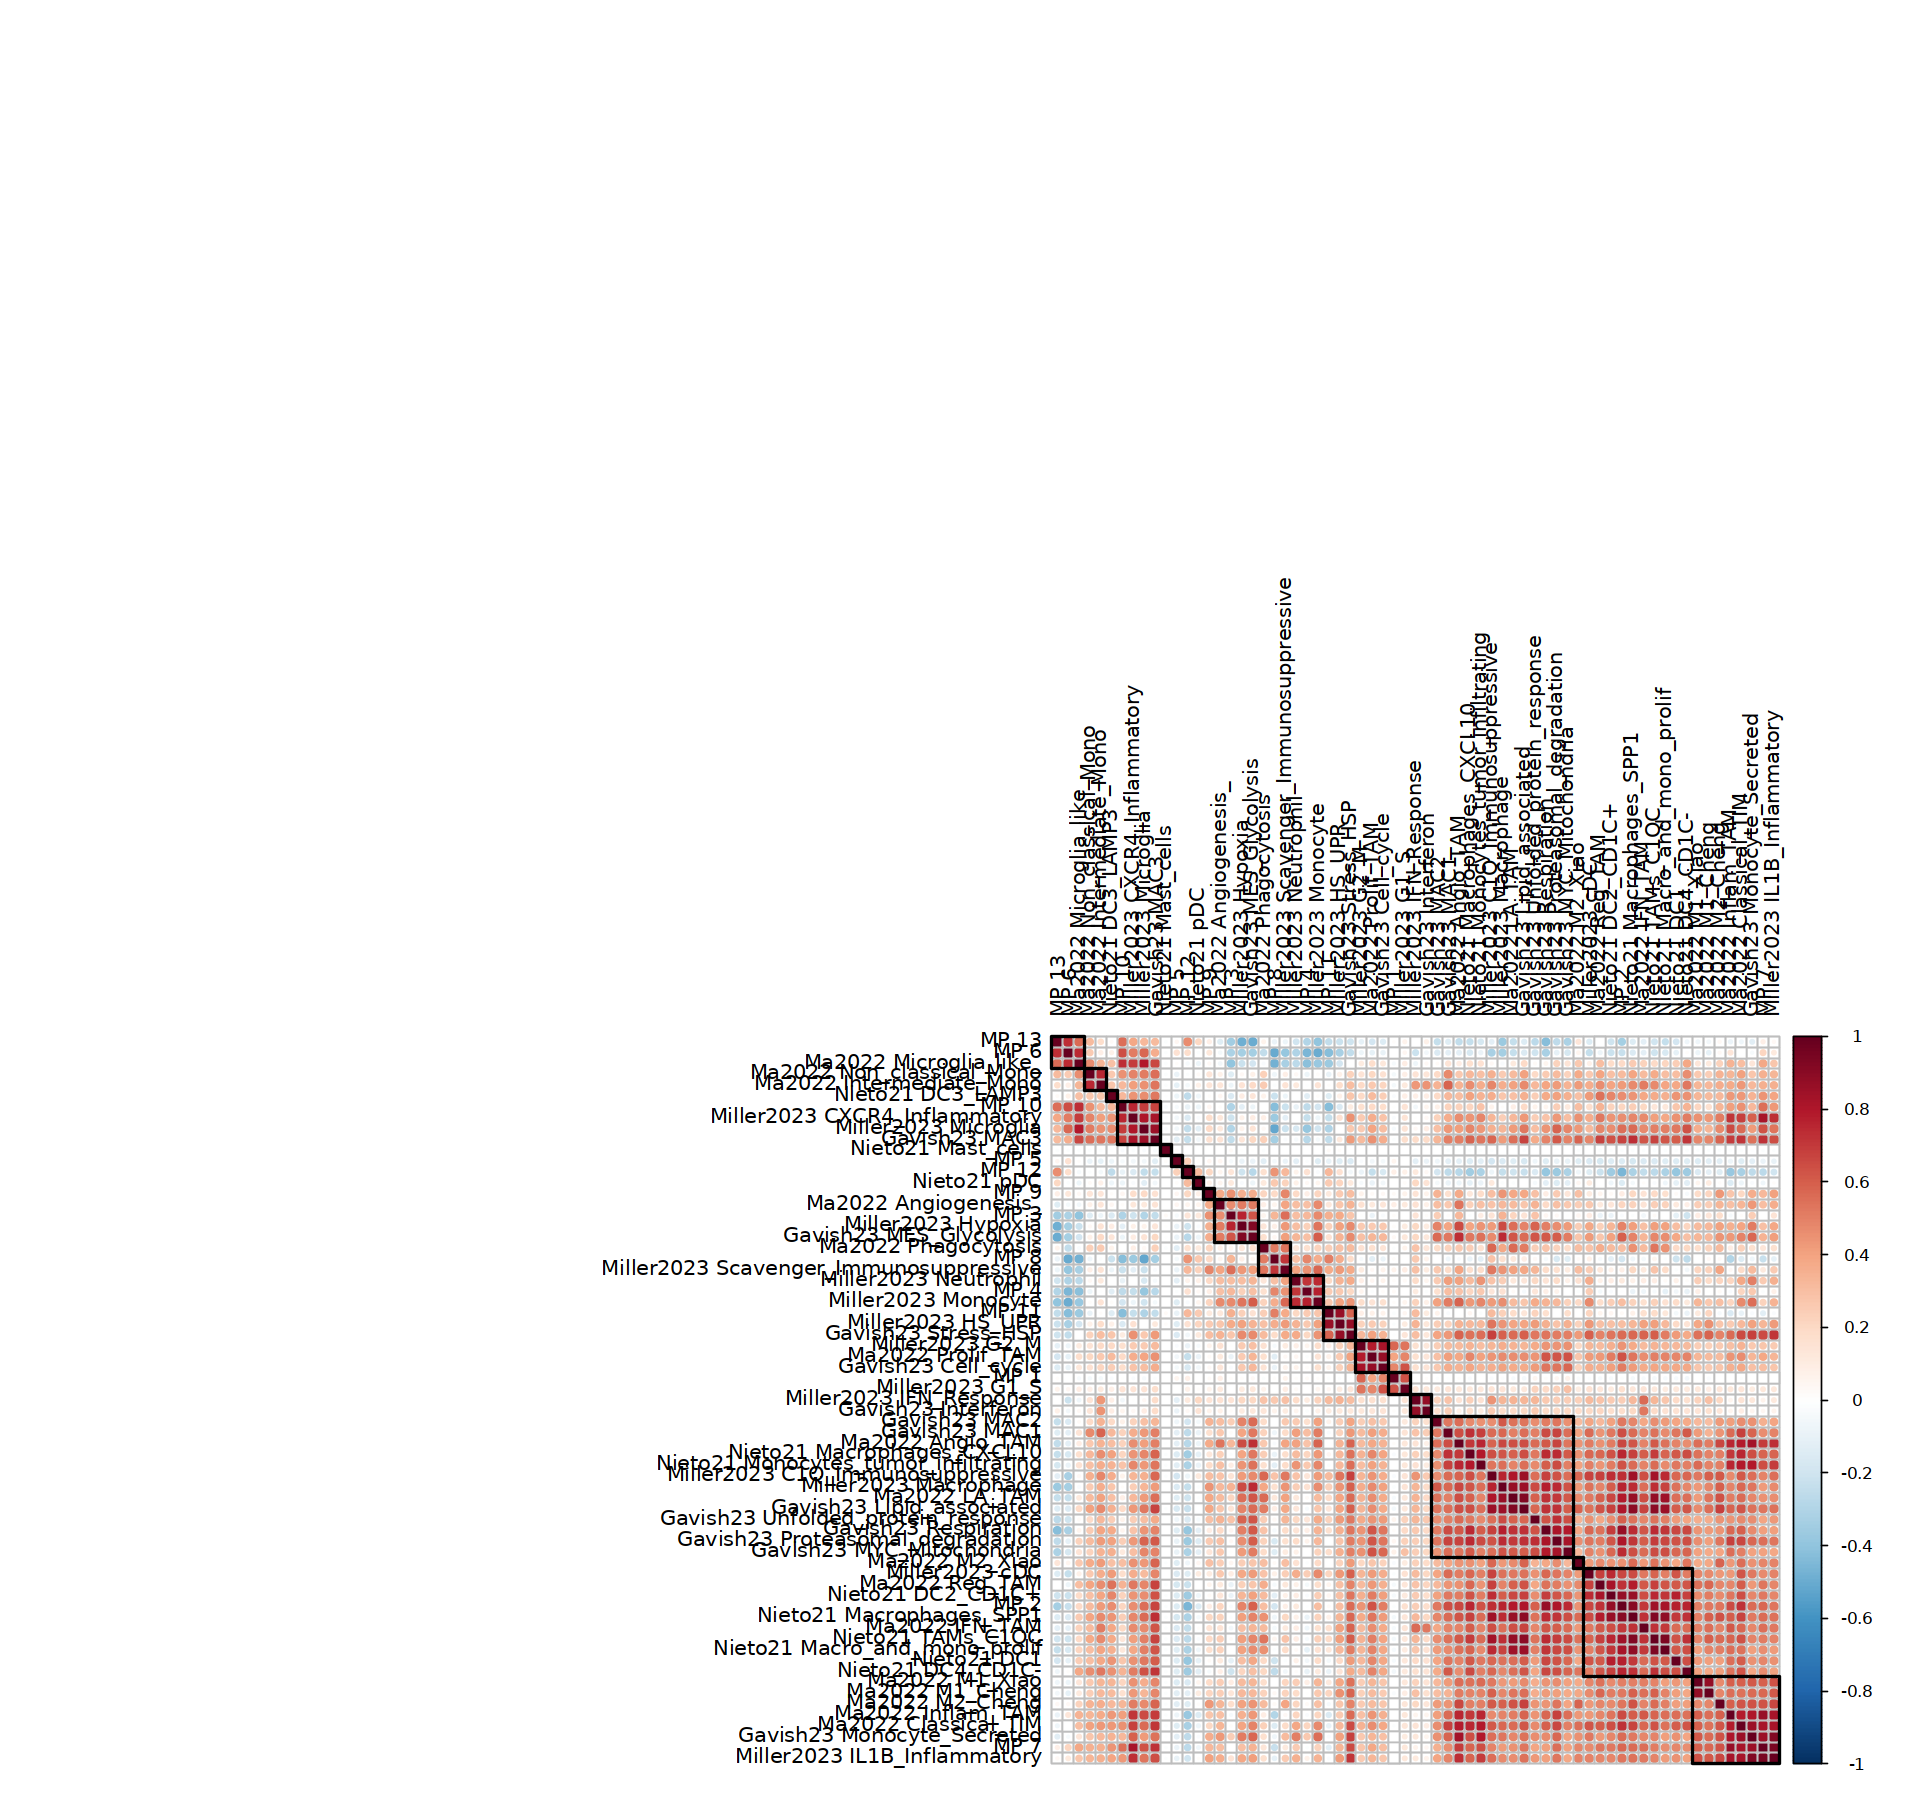

In [19]:
#Plot correlation matrix
options(repr.plot.height = 15, repr.plot.width = 16)
corrplot::corrplot(d_corrhtmp, type = "full", 
    order = "hclust", hclust.method = "complete",
    tl.col = "black", tl.srt = 90,
    addrect = 20, rect.col = "black", rect.lwd = 2,
    col = rev(corrplot::COL2("RdBu")),
    p.mat = dTest_corrhtmp$p, sig.level = 0.05, insig = "blank"
    )

In [20]:
pdf('figures/correlation_heatmap_myeloid_MP_and_signatures_nomito_noribo_UCell_FINAL.pdf', 
    width = 15, height = 15)
corrplot::corrplot(d_corrhtmp, type = "full", 
    order = "hclust", hclust.method = "complete",
    tl.col = "black", tl.srt = 90,
    addrect = 20, rect.col = "black", rect.lwd = 2,
    col = rev(corrplot::COL2("RdBu")),
    p.mat = dTest_corrhtmp$p, sig.level = 0.05, insig = "blank"
    )
dev.off()

png 
  2